In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print('✅ Libraries imported!')

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/tamil_nadu_waterborne_disease_data.csv')
print(f'✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')

✅ Data loaded: 1008 rows, 19 columns


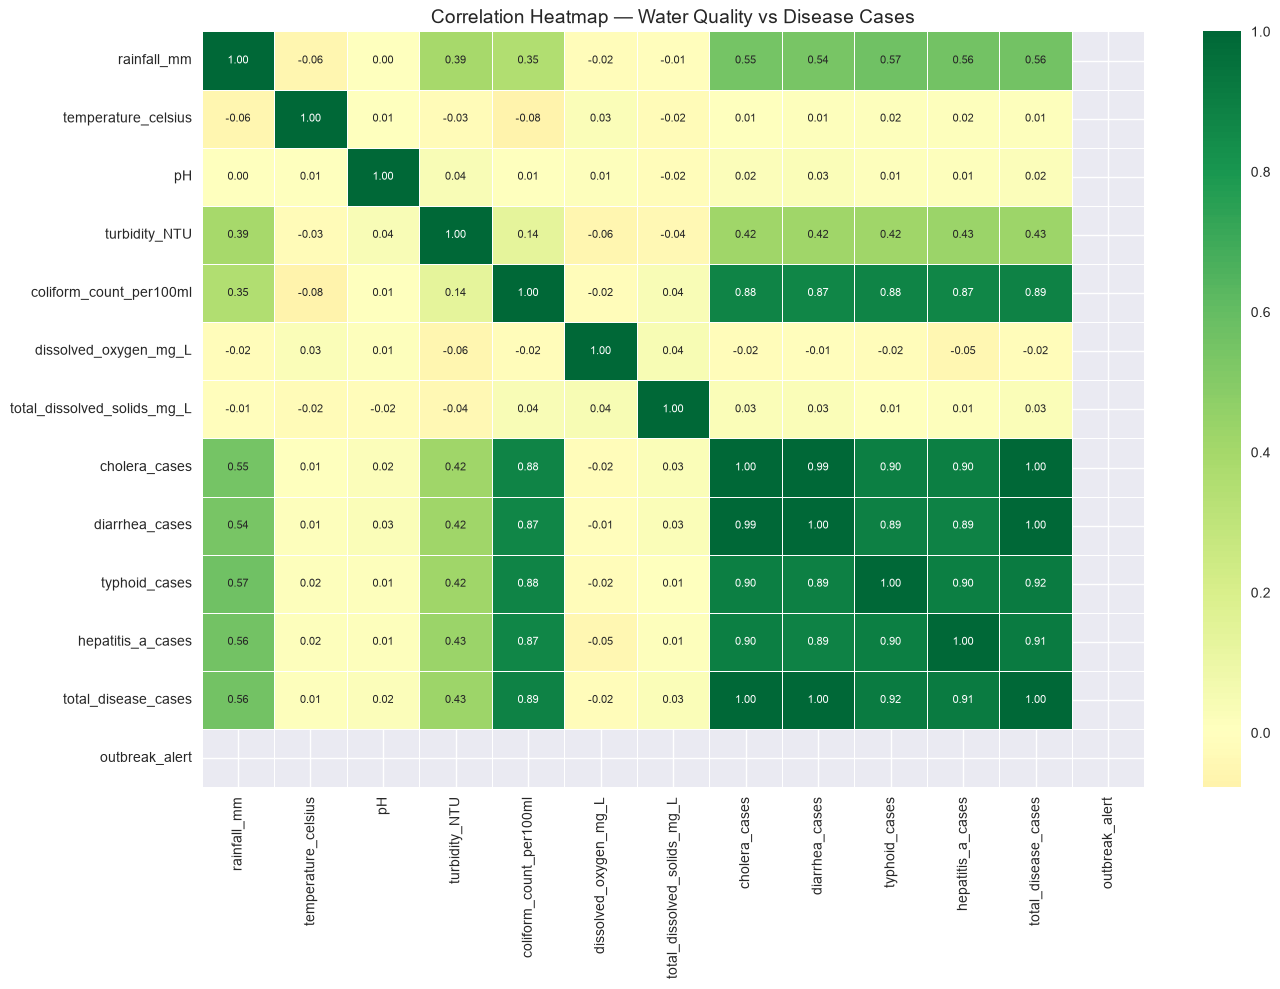

✅ Correlation heatmap saved!


In [3]:
# Select only numerical columns
numeric_cols = ['rainfall_mm', 'temperature_celsius', 'pH',
                'turbidity_NTU', 'coliform_count_per100ml',
                'dissolved_oxygen_mg_L',
                'total_dissolved_solids_mg_L',
                'cholera_cases', 'diarrhea_cases',
                'typhoid_cases', 'hepatitis_a_cases',
                'total_disease_cases', 'outbreak_alert']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Water Quality vs Disease Cases',
          fontsize=14)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150)
plt.show()
print('✅ Correlation heatmap saved!')

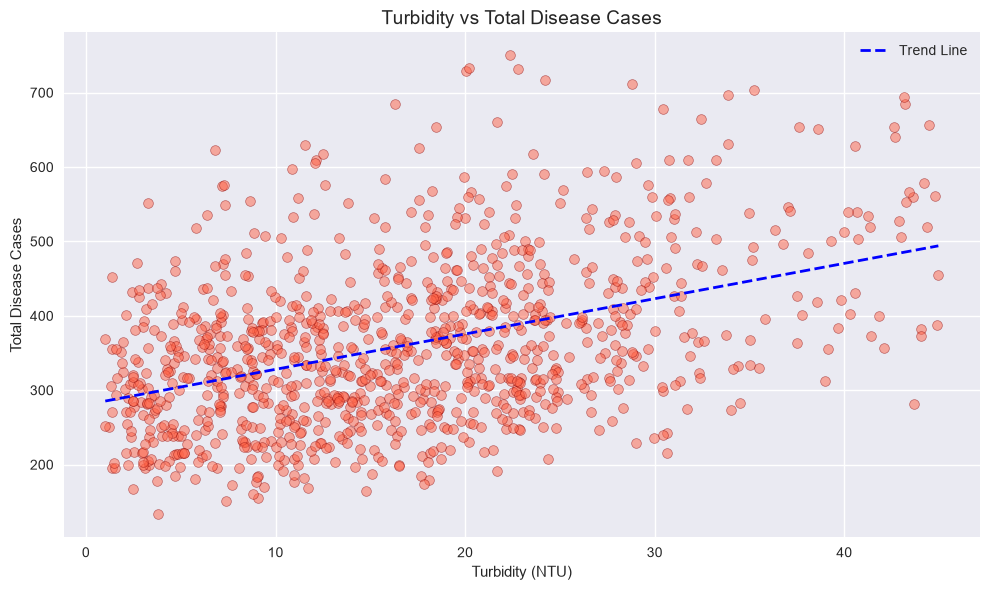

✅ Scatter plot saved!


In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(df['turbidity_NTU'],
            df['total_disease_cases'],
            alpha=0.5,
            color='tomato',
            edgecolors='darkred',
            linewidth=0.5)
plt.title('Turbidity vs Total Disease Cases', fontsize=14)
plt.xlabel('Turbidity (NTU)')
plt.ylabel('Total Disease Cases')

# Add trend line
z = np.polyfit(df['turbidity_NTU'],
               df['total_disease_cases'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['turbidity_NTU']),
         p(sorted(df['turbidity_NTU'])),
         'b--', linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/turbidity_vs_disease.png', dpi=150)
plt.show()
print('✅ Scatter plot saved!')

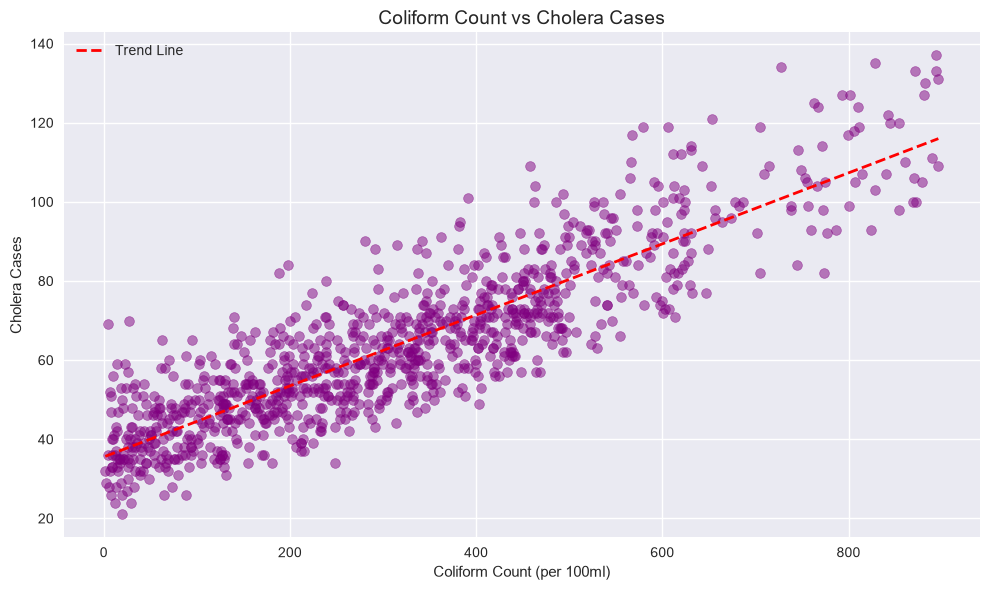

✅ Chart saved!


In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(df['coliform_count_per100ml'],
            df['cholera_cases'],
            alpha=0.5,
            color='purple',
            linewidth=0.5)
plt.title('Coliform Count vs Cholera Cases', fontsize=14)
plt.xlabel('Coliform Count (per 100ml)')
plt.ylabel('Cholera Cases')

z = np.polyfit(df['coliform_count_per100ml'],
               df['cholera_cases'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['coliform_count_per100ml']),
         p(sorted(df['coliform_count_per100ml'])),
         'r--', linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/coliform_vs_cholera.png', dpi=150)
plt.show()
print('✅ Chart saved!')

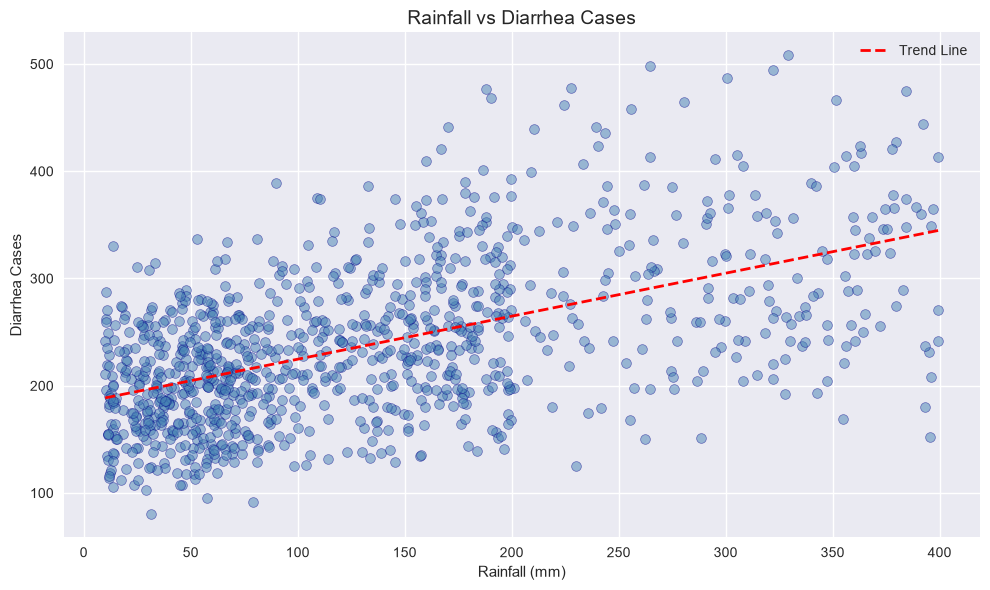

✅ Chart saved!


In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['rainfall_mm'],
            df['diarrhea_cases'],
            alpha=0.5,
            color='steelblue',
            edgecolors='darkblue',
            linewidth=0.5)
plt.title('Rainfall vs Diarrhea Cases', fontsize=14)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Diarrhea Cases')

z = np.polyfit(df['rainfall_mm'],
               df['diarrhea_cases'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['rainfall_mm']),
         p(sorted(df['rainfall_mm'])),
         'r--', linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/rainfall_vs_diarrhea.png', dpi=150)
plt.show()
print('✅ Chart saved!')

<Figure size 1200x600 with 0 Axes>

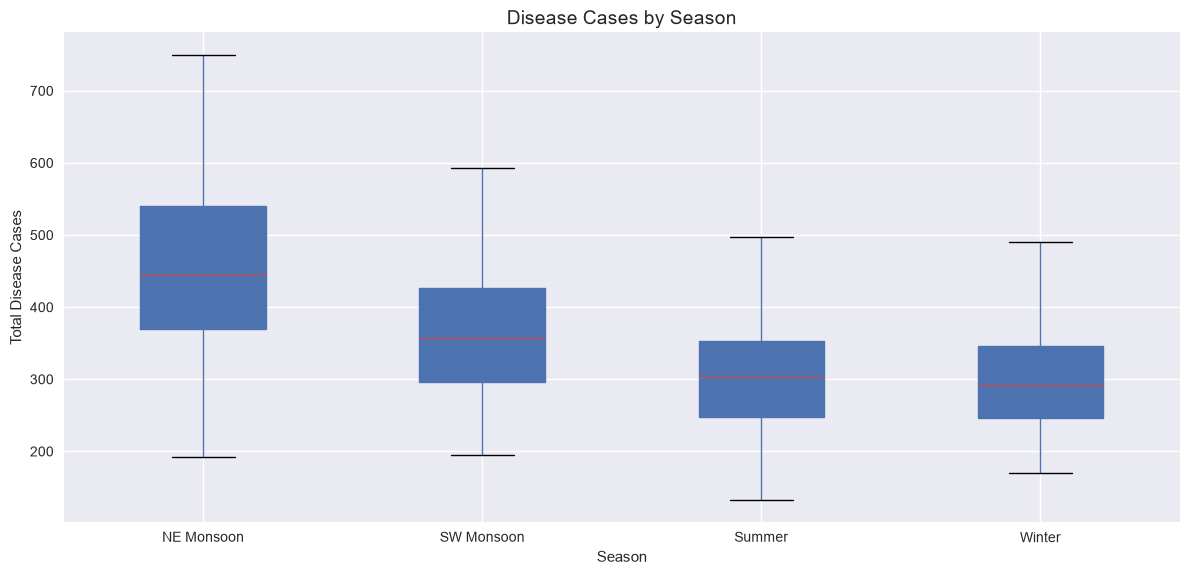

✅ Box plot saved!


In [8]:
# Add season column
def get_season(month):
    if month in [10, 11, 12]:
        return 'NE Monsoon'
    elif month in [6, 7, 8, 9]:
        return 'SW Monsoon'
    elif month in [3, 4, 5]:
        return 'Summer'
    else:
        return 'Winter'

df['season'] = df['month'].apply(get_season)

plt.figure(figsize=(12, 6))
season_order = ['NE Monsoon', 'SW Monsoon', 'Summer', 'Winter']
colors = ['#ff6b6b', '#48dbfb', '#feca57', '#a29bfe']

bp = df.boxplot(column='total_disease_cases',
                by='season',
                figsize=(12, 6),
                patch_artist=True)
plt.title('Disease Cases by Season', fontsize=14)
plt.suptitle('')
plt.xlabel('Season')
plt.ylabel('Total Disease Cases')
plt.tight_layout()
plt.savefig('../reports/seasonal_boxplot.png', dpi=150)
plt.show()
print('✅ Box plot saved!')

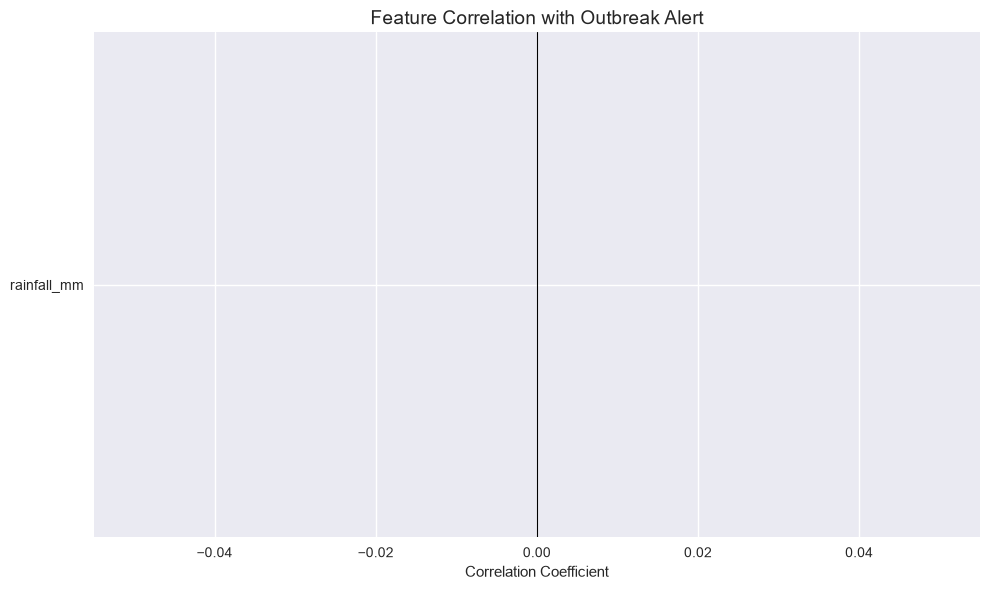


📊 Top Positive Correlations with Outbreak:
Series([], Name: outbreak_alert, dtype: float64)

📊 Top Negative Correlations with Outbreak:
Series([], Name: outbreak_alert, dtype: float64)


In [9]:
# Find strongest correlations with outbreak_alert
correlations = df[numeric_cols].corr()['outbreak_alert'].drop(
    'outbreak_alert').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations]
plt.barh(correlations.index, correlations.values, color=colors)
plt.title('Feature Correlation with Outbreak Alert', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../reports/feature_correlations.png', dpi=150)
plt.show()

print('\n📊 Top Positive Correlations with Outbreak:')
print(correlations[correlations > 0].round(3))
print('\n📊 Top Negative Correlations with Outbreak:')
print(correlations[correlations < 0].round(3))

In [10]:
print('='*55)
print('📊 KEY FINDINGS - EDA PART 2')
print('='*55)

corr = df[numeric_cols].corr()['total_disease_cases']
print('\n🔑 Strongest Correlations with Disease Cases:')
print(corr.drop('total_disease_cases').sort_values(
    ascending=False).round(3))

season_avg = df.groupby('season')[
    'total_disease_cases'].mean().sort_values(ascending=False)
print('\n🌦️ Average Cases by Season:')
print(season_avg.round(0))

print('\n✅ EDA Part 2 Complete!')

📊 KEY FINDINGS - EDA PART 2

🔑 Strongest Correlations with Disease Cases:
diarrhea_cases                 0.998
cholera_cases                  0.995
typhoid_cases                  0.918
hepatitis_a_cases              0.912
coliform_count_per100ml        0.886
rainfall_mm                    0.557
turbidity_NTU                  0.425
total_dissolved_solids_mg_L    0.027
pH                             0.023
temperature_celsius            0.013
dissolved_oxygen_mg_L         -0.017
outbreak_alert                   NaN
Name: total_disease_cases, dtype: float64

🌦️ Average Cases by Season:
season
NE Monsoon    459.0
SW Monsoon    362.0
Summer        300.0
Winter        299.0
Name: total_disease_cases, dtype: float64

✅ EDA Part 2 Complete!
